# The Lorenz Attractor

**Alejandro Jaramillo Moreno**  
*Hidroclimatología Tropical*  
Instituto de Ciencias de la Atmósfera y Cambio Climático  
Universidad Nacional Autónoma de México  

---

## Overview  

This notebook explores a simplified form of the equations introduced by **Edward Lorenz (1963)**, which illustrate how small differences in initial conditions can significantly impact the evolution of a dynamical system.  

The Lorenz system is defined by the following set of differential equations:

$X'= -\sigma (X-Y)$

$Y' = -XZ +  rX -Y$

$Z' = XY- bZ$

- X, Y, and Z represent system state variables.  
- $\sigma$, r, and b are parameters governing the system dynamics.  

This system is widely recognized for its chaotic behavior under certain parameter values, leading to the well-known **Lorenz attractor**.  

---

## References  

Lorenz, E. N. (1963). Deterministic nonperiodic flow. *Journal of the Atmospheric Sciences, 20*(2), 130–141. [https://doi.org/10.1175/1520-0469(1963)020<0130:DNF>2.0.CO;2](https://doi.org/10.1175/1520-0469(1963)020%3C0130:DNF%3E2.0.CO;2)  


In [1]:
# Import packages

import numpy as np
import pandas as pd
from scipy.integrate import odeint
import matplotlib.pyplot as plt
from matplotlib import rc
from mpl_toolkits.mplot3d import Axes3D

import matplotlib as mpl
mpl.rcParams['animation.embed_limit'] = 10  # Allow up to 50 MB

import matplotlib.animation

plt.rcParams["animation.html"] = "jshtml"
plt.rcParams['figure.dpi'] = 100

In [2]:
# Define the function with the couple differential equations of Lorenz (1963)

def lorenz(v, t, sigma, b, r):
    """
    Set of coupled differential equations proposed in Lorenz (1963)
    DX/Dt = -sigma*(X - Y)
    DY/Dt = -X*Z +  r*X - Y
    DZ/Dt = X*Y- b*Z
    """
    x, y, z = v
    xp = -sigma*(x-y)
    yp = r*x-y-x*z
    zp = x*y-b*z
    return xp, yp, zp


In [3]:
# USER DEFINED PARAMETERS
# Lorenz parameters and initial conditions


# Lorenz parameters
sigma,b,r = 10,2.667,28

# Maximum time point and total number of time points
tmax, n = 100, 10000
t = np.linspace(0, tmax, n)


# Initial Contitions IC1 and IC2.
# IC2 is defined as a little difference from IC1.

# IC1
x0_1,y0_1,z0_1 = 0, 1, 1.05

# IC2
x0_2,y0_2,z0_2 = 0, 1, 1.06

In [4]:
f0 = odeint(lorenz,(x0_1,y0_1,z0_1),t,args=(sigma,b,r))
x,y,z = f0.T
df1 = pd.DataFrame({'X':x,'Y':y,'Z':z},index=t)


f0 = odeint(lorenz,(x0_2,y0_2,z0_2),t,args=(sigma,b,r))
x,y,z = f0.T
df2 = pd.DataFrame({'X':x,'Y':y,'Z':z},index=t)

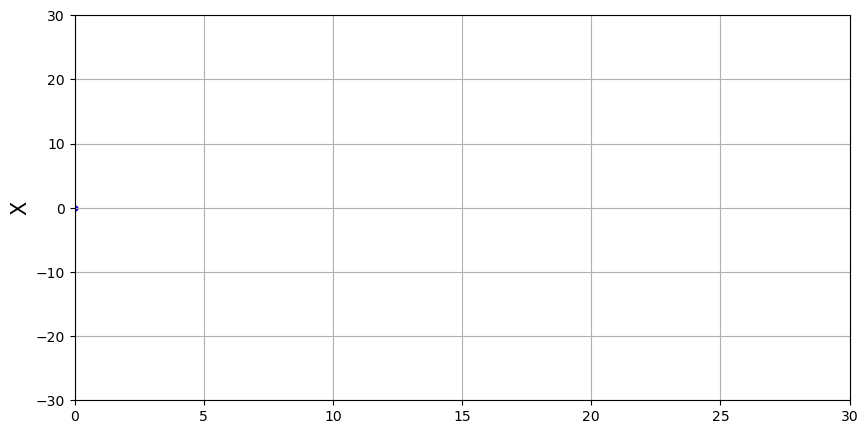

In [5]:
def animate_time_series(t):
    ax.clear()
    
    ax.plot(df1[df1.index<=30].index.values[:t],df1[df1.index<=30]['X'].values[:t],color='red',ls=':',lw=1.0)
    ax.scatter(df1[df1.index<=30].index.values[t],df1[df1.index<=30]['X'].values[t],color='red',s=10)
    
    
    ax.plot(df2[df2.index<=30].index.values[:t],df2[df2.index<=30]['X'].values[:t],color='blue',ls=':',lw=1.0)
    ax.scatter(df2[df2.index<=30].index.values[t],df2[df2.index<=30]['X'].values[t],color='blue',s=10)
    
    ax.set_ylim(-30,30)
    ax.set_xlim(0,30)
    ax.set_ylabel(r'X',size=15)
    ax.grid(which='both')    
    
plt.ioff()
fig, ax = plt.subplots(figsize=(10,5))

frames = list(range(0, len(df1[df1.index<=30]), 20)) 
anim = matplotlib.animation.FuncAnimation(fig, animate_time_series, frames=frames, interval=100)

In [6]:
anim

In [7]:
def animate(t):
    ax.clear()
    ax.plot(df1['X'].values[:t],df1['Y'].values[:t],df1['Z'].values[:t],color='red',lw=1.0,ls='--')
    ax.scatter(df1['X'].values[t],df1['Y'].values[t],df1['Z'].values[t],color='red',s=10)
    
    ax.plot(df2['X'].values[:t],df2['Y'].values[:t],df2['Z'].values[:t],color='blue',lw=1.0,ls='--')
    ax.scatter(df2['X'].values[t],df2['Y'].values[t],df2['Z'].values[t],color='blue',s=10)
    
    ax.set_xlabel(r'X',size=15)
    ax.set_ylabel(r'Y',size=15)
    ax.set_zlabel(r'Z',size=15)
    #ax.set_title('T = {}'.format(t))
    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False
    ax.set_xlim(-30,30)
    ax.set_ylim(-30,30)
    ax.set_zlim(0,50)

plt.rcParams["animation.html"] = "jshtml"
plt.rcParams['figure.dpi'] = 100
plt.ioff()
fig, ax = plt.subplots(figsize=(5,5),subplot_kw={'projection': '3d'})

frames = list(range(0, len(df1), 50)) 
anim2 = matplotlib.animation.FuncAnimation(fig, animate, frames=frames, interval=100)

In [ ]:
anim2